In [13]:
import pandas as pd

In [14]:
# 读取CSV文件
df = pd.read_csv('output/node_13e.csv')

# 将站点和出入口分开
stations = df[df['node'].str.startswith('s')].sort_values(by='distance').reset_index(drop=True)
entrances = df[df['node'].str.startswith('e')].sort_values(by='distance').reset_index(drop=True)
# stations 和 entrances 也是dataframe 类型,包含node和distance列

# 定义一个函数来找到两个出入口之间经过的站点，并按方向排序
def find_stations_between(start, end):
    start_distance = entrances.loc[entrances['node'] == start, 'distance'].values[0]
    end_distance = entrances.loc[entrances['node'] == end, 'distance'].values[0]
    
    if start_distance < end_distance:
        passing_stations = stations[(stations['distance'] >= start_distance) & (stations['distance'] <= end_distance)]
    else:
        passing_stations = stations[(stations['distance'] <= start_distance) & (stations['distance'] >= end_distance)].sort_values(by='distance', ascending=False)
    
    return passing_stations['node'].tolist(), abs(end_distance - start_distance)

# 双向的O-D对
# 生成子路径列表
subpaths = []
path_id = 1
minL=200  # 只挑选路径长度大于等于200的O-D对

print(find_stations_between('e1', 'e5'))

for i, start in entrances.iterrows():
    for j, end in entrances.iterrows():
        if start['node'] != end['node']: # 确保不生成同一出入口的路径
            stations_between, path_length = find_stations_between(start['node'], end['node'])
            if path_length >= minL and stations_between: # 只保留路径长度大于等于200且有经过站点的路径
                subpaths.append([f'p{path_id}', start['node'], end['node'], ','.join(stations_between)])
                path_id += 1

# 转换为DataFrame并保存为CSV
subpaths_df = pd.DataFrame(subpaths, columns=['PATH', 'SOURCE', 'ROOT', 'STATIONS'])
subpaths_df.to_csv('subpaths_13e.csv', index=False)
print(subpaths_df)



(['s1', 's2', 's3'], np.float64(340.0))
     PATH SOURCE ROOT                STATIONS
0      p1     e1   e4                s1,s2,s3
1      p2     e1   e5                s1,s2,s3
2      p3     e1   e6             s1,s2,s3,s4
3      p4     e1   e7             s1,s2,s3,s4
4      p5     e1   e8       s1,s2,s3,s4,s5,s6
..    ...    ...  ...                     ...
109  p110    e13   e7  s11,s10,s9,s8,s7,s6,s5
110  p111    e13   e8        s11,s10,s9,s8,s7
111  p112    e13   e9           s11,s10,s9,s8
112  p113    e13  e10              s11,s10,s9
113  p114    e13  e11              s11,s10,s9

[114 rows x 4 columns]


In [15]:
# 读取CSV文件的第一个sheet
df = pd.read_csv('subpaths_13e.csv')

# 创建一个空字典来存储路径信息和对应的弧
paths = {}

# 将路径信息存储到字典中
for index, row in df.iterrows():
    path_name = row['PATH']
    source = row['SOURCE']
    root = row['ROOT']
    stations = row['STATIONS'].split(',')
    
    # 生成路径中的弧
    arcs = [(source, stations[0])]
    for i in range(len(stations) - 1):
        arcs.append((stations[i], stations[i+1]))
    arcs.append((stations[-1], root))
    
    paths[path_name] = {'source': source, 'root': root, 'stations': stations, 'arcs': arcs}

paths

{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e4')]},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e5')]},
 'p3': {'source': 'e1',
  'root': 'e6',
  'stations': ['s1', 's2', 's3', 's4'],
  'arcs': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 's4'),
   ('s4', 'e6')]},
 'p4': {'source': 'e1',
  'root': 'e7',
  'stations': ['s1', 's2', 's3', 's4'],
  'arcs': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 's4'),
   ('s4', 'e7')]},
 'p5': {'source': 'e1',
  'root': 'e8',
  'stations': ['s1', 's2', 's3', 's4', 's5', 's6'],
  'arcs': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 's4'),
   ('s4', 's5'),
   ('s5', 's6'),
   ('s6', 'e8')]},
 'p6': {'source': 'e1',
  'root': 'e9',
  'stations': ['s1', 's2', 's3', 's4', 's5', 's6', 's7'],
  'arcs': [('e1', 's1'),
   ('s1', 's2'),
   

In [16]:
# 打印存储的路径信息和对应的弧
for path_name, path_info in paths.items():
    print(f"Path: {path_name}")
    print("Source:", path_info['source'])
    print("Root:", path_info['root'])
    print("Stations:", path_info['stations'])
    print("Arcs:", path_info['arcs'])
    print()

Path: p1
Source: e1
Root: e4
Stations: ['s1', 's2', 's3']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e4')]

Path: p2
Source: e1
Root: e5
Stations: ['s1', 's2', 's3']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e5')]

Path: p3
Source: e1
Root: e6
Stations: ['s1', 's2', 's3', 's4']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 's4'), ('s4', 'e6')]

Path: p4
Source: e1
Root: e7
Stations: ['s1', 's2', 's3', 's4']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 's4'), ('s4', 'e7')]

Path: p5
Source: e1
Root: e8
Stations: ['s1', 's2', 's3', 's4', 's5', 's6']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 's4'), ('s4', 's5'), ('s5', 's6'), ('s6', 'e8')]

Path: p6
Source: e1
Root: e9
Stations: ['s1', 's2', 's3', 's4', 's5', 's6', 's7']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 's4'), ('s4', 's5'), ('s5', 's6'), ('s6', 's7'), ('s7', 'e9')]

Path: p7
Source: e1
Root: e10
Stations: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']

In [17]:
import numpy as np
dist = pd.read_csv('output/dist_13e.csv',header=0,index_col=0)
dist = dist.map(np.abs)
dist


,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,...,e4,e5,e6,e7,e8,e9,e10,e11,e12,e13
s1,0.0,47.0,241.0,361.0,528.0,599.0,664.0,786.0,906.0,1013.0,...,265.0,326.0,426.0,493.0,620.0,736.0,808.0,873.0,981.0,1126.0
s2,47.0,0.0,194.0,314.0,481.0,552.0,617.0,739.0,859.0,966.0,...,218.0,279.0,379.0,446.0,573.0,689.0,761.0,826.0,934.0,1079.0
s3,241.0,194.0,0.0,120.0,287.0,358.0,423.0,545.0,665.0,772.0,...,24.0,85.0,185.0,252.0,379.0,495.0,567.0,632.0,740.0,885.0
s4,361.0,314.0,120.0,0.0,167.0,238.0,303.0,425.0,545.0,652.0,...,96.0,35.0,65.0,132.0,259.0,375.0,447.0,512.0,620.0,765.0
s5,528.0,481.0,287.0,167.0,0.0,71.0,136.0,258.0,378.0,485.0,...,263.0,202.0,102.0,35.0,92.0,208.0,280.0,345.0,453.0,598.0
s6,599.0,552.0,358.0,238.0,71.0,0.0,65.0,187.0,307.0,414.0,...,334.0,273.0,173.0,106.0,21.0,137.0,209.0,274.0,382.0,527.0
s7,664.0,617.0,423.0,303.0,136.0,65.0,0.0,122.0,242.0,349.0,...,399.0,338.0,238.0,171.0,44.0,72.0,144.0,209.0,317.0,462.0
s8,786.0,739.0,545.0,425.0,258.0,187.0,122.0,0.0,120.0,227.0,...,521.0,460.0,360.0,293.0,166.0,50.0,22.0,87.0,195.0,340.0
s9,906.0,859.0,665.0,545.0,378.0,307.0,242.0,120.0,0.0,107.0,...,641.0,580.0,480.0,413.0,286.0,170.0,98.0,33.0,75.0,220.0
s10,1013.0,966.0,772.0,652.0,485.0,414.0,349.0,227.0,107.0,0.0,...,748.0,687.0,587.0,520.0,393.0,277.0,205.0,140.0,32.0,113.0


In [18]:
RangeS = 300 # 短续航电池里程
RangeL = 400 # 长续航电池里程

for path_name, path_info in paths.items():
    path_info['AS'] = path_info['arcs'].copy() # 初始化AS为原始弧列表
    path_info['AL'] = path_info['arcs'].copy() # 初始化AL为原始弧列表
    
    for station in path_info['stations']:

        # Step1 Add Arc from source node
        # 这里的条件是如果source节点和station之间的距离小于等于RangeS/2，并且这个弧不在AS或AL中，就添加这个弧到AS或AL中
        if dist[path_info['source']][station]<=RangeS/2 and (path_info['source'],station) not in path_info['AS']:
            path_info['AS'].append((path_info['source'],station))

        if dist[path_info['source']][station]<=RangeL/2 and (path_info['source'],station) not in path_info['AL']:
            path_info['AL'].append((path_info['source'],station))

        # Step2 Add Arc to root node
        # 这里的条件是如果station节点和root节点之间的距离小于等于RangeS/2，并且这个弧不在AS或AL中，就添加这个弧到AS或AL中
        if dist[station][path_info['root']]<=RangeS/2 and (station,path_info['root']) not in path_info['AS']:
            path_info['AS'].append((station,path_info['root']))
        if dist[station][path_info['root']]<=RangeL/2 and (station,path_info['root']) not in path_info['AL']:
            path_info['AL'].append((station,path_info['root']))

    # Step3 Add Arc between stations
    # 注意为什么是+2，因为+1已经在初始化AS和AL的时候添加了相邻站点之间的弧了，所以这里要跳过相邻站点之间的弧
    for i in range(len(path_info['stations'])-2):
        for j in range(i + 2, len(path_info['stations'])):
            station1 = path_info['stations'][i]
            station2 = path_info['stations'][j]

            if dist[station1][station2]<=RangeS:
                path_info['AS'].append((station1,station2))
            if dist[station1][station2]<=RangeL:
                path_info['AL'].append((station1,station2))
            else:
                break

paths

{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e4')],
  'AS': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e4'),
   ('e1', 's2'),
   ('s1', 's3')],
  'AL': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e4'),
   ('e1', 's2'),
   ('s1', 's3')]},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e5')],
  'AS': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e5'),
   ('e1', 's2'),
   ('s1', 's3')],
  'AL': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e5'),
   ('e1', 's2'),
   ('s1', 's3')]},
 'p3': {'source': 'e1',
  'root': 'e6',
  'stations': ['s1', 's2', 's3', 's4'],
  'arcs': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 's4'),
   ('s4', 'e6')],
  'AS': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 's4'),
   ('s4', 'e6'),
   ('e1', 's2

In [19]:
minDistS=200 #设置两个站点之间的距离阈值
minDistL=300

def dfs(graph, current, end, path, paths):
    '''深度优先搜索，找到从current到end的所有路径'''
    path.append(current)
    if current == end:
        paths.append(path.copy())
    else:
        for neighbor in graph[current]:
            if neighbor not in path:
                dfs(graph, neighbor, end, path, paths)
    path.pop() # 恢复现场，以便继续搜索其他路径

def nodes_to_arcs(nodes):
    '''将路径中的节点列表转换为弧列表'''
    arcs = []
    for i in range(len(nodes) - 1):
        arcs.append((nodes[i], nodes[i+1]))
    return arcs

def cut_arcs(arcs,source,root,stations,min_dist):

    # 构建图形表示
    # 这里的图是一个邻接表，key是节点，value是一个列表，包含所有从这个节点出发的弧的终点
    # 并且图是针对于每一个O-D对的AS或AL来构建的，所以每个O-D对的AS或AL都会有一个对应的图
    graph = {}
    for arc in arcs:
        if arc[0] not in graph:
            graph[arc[0]] = []
        graph[arc[0]].append(arc[1])


    #print(graph)
    # 找到从起点到终点的所有路径
    
    all_paths = []
    dfs(graph, source, root, [], all_paths)
    # 没有返回值，但all_paths会被修改，包含所有从source到root的路径，每条路径是一个节点列表

    all_paths_arcs = [nodes_to_arcs(path) for path in all_paths]
    #path_info['strategyS']=all_paths

    # 筛选距离小于 min_dist 且仅连接站点的弧
    filtered_arcs = [arc for arc in path_info['AS'] if dist[arc[0]][arc[1]] < min_dist and arc[0] in stations and arc[1] in stations]

    # 根据弧的距离排序
    sorted_arcs = sorted(filtered_arcs, key=lambda x: dist[x[0]][x[1]])

    # 检查每个距离小于 min_dist 的弧是否在所有路径中都有，如果存在有路径没有这条弧，则从所有路径中移除包含该弧的路径
    for arc in sorted_arcs:
        arc_found_in_all_paths = all(arc in path for path in all_paths_arcs) # 检查弧是否在所有路径中都有
        if not arc_found_in_all_paths: # 如果不在所有路径中（还有其他路径可以包含起点和终点）
            all_paths_arcs = [path for path in all_paths_arcs if arc not in path] # 从所有路径中移除包含该弧的路径

    # 获取所有路径中的弧
    all_arcs = []
    for path in all_paths_arcs:
        all_arcs.extend(path)

    # 将弧列表转换为集合，再取并集
    merged_arcs = list(set(all_arcs))

    return merged_arcs,all_paths_arcs


for path_name, path_info in paths.items():
    path_info['strategyS'],path_info['PATHS']=cut_arcs(path_info['AS'],path_info['source'],path_info['root'],path_info['stations'],minDistS)
    path_info['strategyL'],path_info['PATHL']=cut_arcs(path_info['AL'],path_info['source'],path_info['root'],path_info['stations'],minDistL)

    # strategyS和strategyL分别是经过剪枝后的AS和AL，PATHS和PATHL分别是经过剪枝后的AS和AL对应的路径列表，每条路径是一个弧列表
paths


{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e4')],
  'AS': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e4'),
   ('e1', 's2'),
   ('s1', 's3')],
  'AL': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e4'),
   ('e1', 's2'),
   ('s1', 's3')],
  'strategyS': [('s3', 'e4'), ('e1', 's1'), ('s1', 's3')],
  'PATHS': [[('e1', 's1'), ('s1', 's3'), ('s3', 'e4')]],
  'strategyL': [('s3', 'e4'), ('e1', 's1'), ('s1', 's3')],
  'PATHL': [[('e1', 's1'), ('s1', 's3'), ('s3', 'e4')]]},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e5')],
  'AS': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e5'),
   ('e1', 's2'),
   ('s1', 's3')],
  'AL': [('e1', 's1'),
   ('s1', 's2'),
   ('s2', 's3'),
   ('s3', 'e5'),
   ('e1', 's2'),
   ('s1', 's3')],
  'strategyS': [('e1', 's1'), ('s3', 'e5'), ('s

In [20]:
import json
# 保存到文件
with open('data_13e.json', 'w') as f:
    json.dump(paths, f, ensure_ascii=False, indent=4)

In [21]:
# 从文件读取
with open('data_13e.json', 'r') as f:
    loaded_data = json.load(f)

print(loaded_data)

{'p1': {'source': 'e1', 'root': 'e4', 'stations': ['s1', 's2', 's3'], 'arcs': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e4']], 'AS': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e4'], ['e1', 's2'], ['s1', 's3']], 'AL': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e4'], ['e1', 's2'], ['s1', 's3']], 'strategyS': [['s3', 'e4'], ['e1', 's1'], ['s1', 's3']], 'PATHS': [[['e1', 's1'], ['s1', 's3'], ['s3', 'e4']]], 'strategyL': [['s3', 'e4'], ['e1', 's1'], ['s1', 's3']], 'PATHL': [[['e1', 's1'], ['s1', 's3'], ['s3', 'e4']]]}, 'p2': {'source': 'e1', 'root': 'e5', 'stations': ['s1', 's2', 's3'], 'arcs': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e5']], 'AS': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e5'], ['e1', 's2'], ['s1', 's3']], 'AL': [['e1', 's1'], ['s1', 's2'], ['s2', 's3'], ['s3', 'e5'], ['e1', 's2'], ['s1', 's3']], 'strategyS': [['e1', 's1'], ['s3', 'e5'], ['s1', 's3']], 'PATHS': [[['e1', 's1'], ['s1', 's3'], ['s3', 'e5']]], 'strategyL': [['e1', 's1

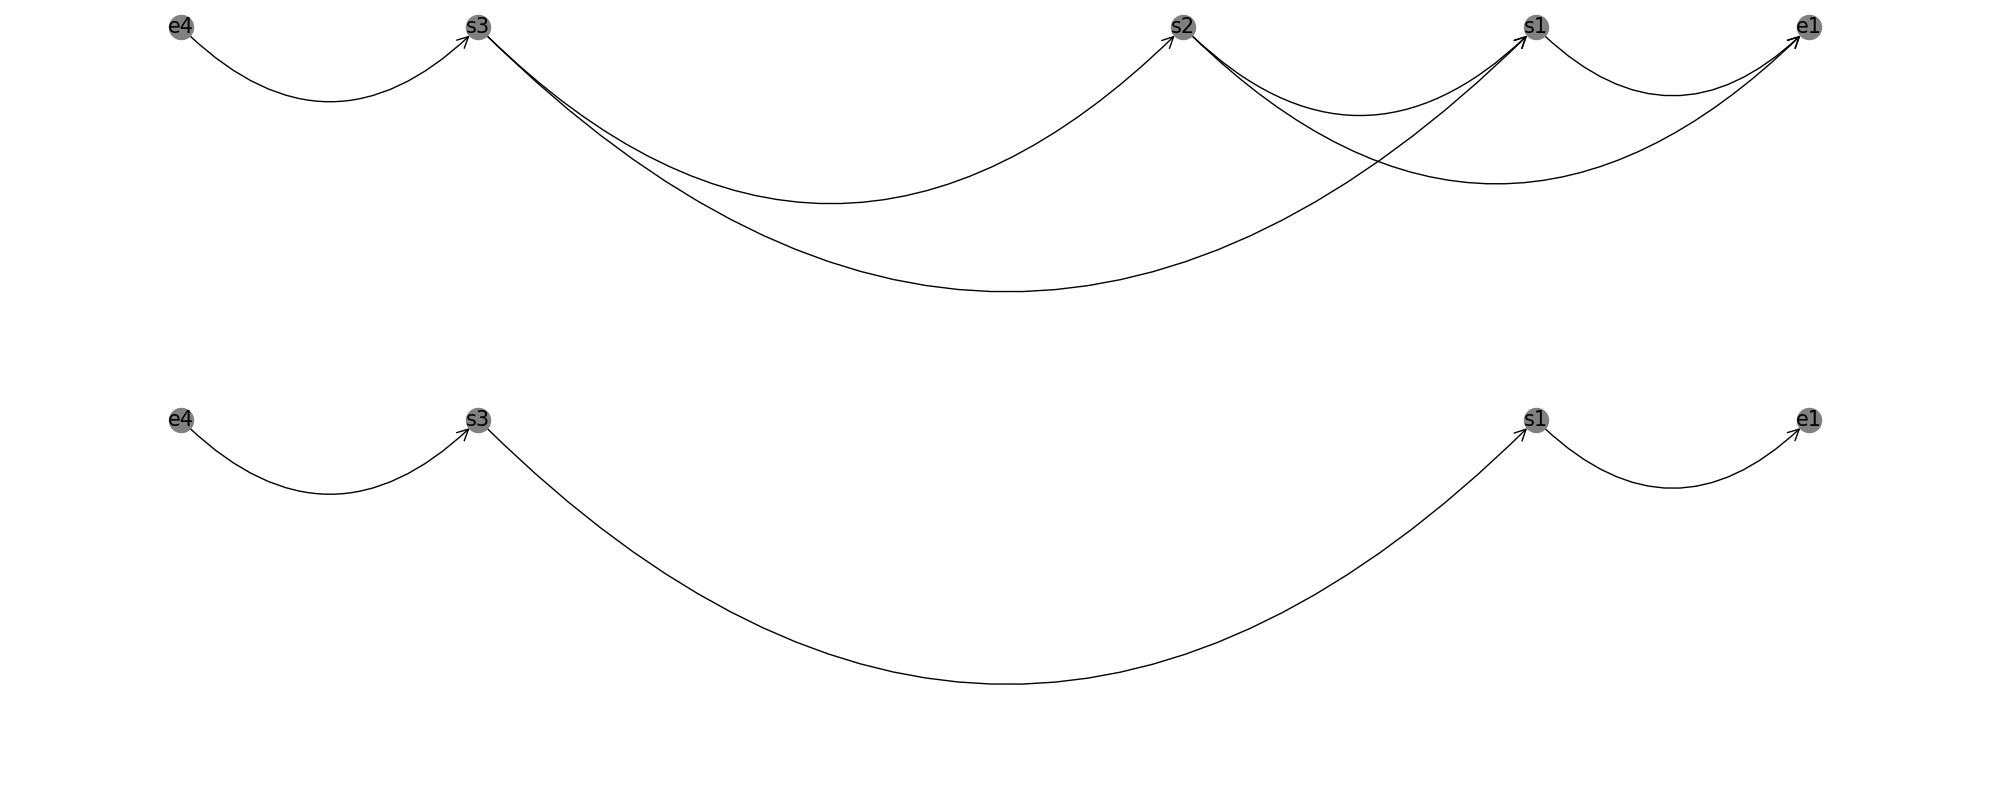

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

# 计算每个节点的位置
def calculate_positions(source, stations, dist):
    positions = {source: 0}
    current_position = 0
    current_station = source

    for station in stations:
        if station in dist.columns and current_station in dist.index:
            current_position += dist[current_station][station]+100
            positions[station] = current_position
            current_station = station

    # 将所有位置转换为 (x, y) 格式，y 设为 0
    positions = {k: (v, 0) for k, v in positions.items()}
    return positions

def draw_network(path_info, Arcs, Strategy, dist):
    G_AS = nx.DiGraph()
    G_strategyS = nx.DiGraph()
    
    source = path_info['source']
    root = path_info['root']
    stations = path_info['stations'] + [root]
    
    # 计算节点位置
    pos = calculate_positions(source, stations, dist)
    
    # 添加AS网络中的弧
    for arc in Arcs:
        G_AS.add_edge(arc[0], arc[1])

    # 添加strategyS网络中的弧
    for arc in Strategy:
        G_strategyS.add_edge(arc[0], arc[1])

    # 创建图形并设置子图布局
    fig, axs = plt.subplots(2, 1, figsize=(20, 8))

    # 绘制第一个子图
    nx.draw(G_AS, pos, ax=axs[0],
            arrowstyle='->', 
            arrowsize=20, 
            width=1,
            with_labels=False, 
            node_size=300, 
            node_color='grey',
            edge_color='black',
            connectionstyle='arc3,rad=0.5')
    nx.draw_networkx_labels(G_AS, pos, ax=axs[0], font_size=15, font_color='black', verticalalignment='center')  # 调整标签的大小和位置


    # 绘制第二个子图
    nx.draw(G_strategyS, pos, ax=axs[1],
            arrowstyle='->', 
            arrowsize=20, 
            width=1,
            with_labels=False, 
            node_size=300, 
            node_color='grey',
            edge_color='black',
            connectionstyle='arc3,rad=0.5')
    nx.draw_networkx_labels(G_strategyS, pos, ax=axs[1], font_size=15, font_color='black', verticalalignment='center')  # 调整标签的大小和位置


    plt.tight_layout()  # 调整子图布局

    plt.show()

draw_network(paths['p28'], paths['p28']['AL'],paths['p28']['strategyL'], dist)